# NB30 — rolling typical profitability, corrected

Repairs the earlier NB30 diagnostic; no portfolio backtest. See the
[original plan](rolling-typical-profitability-plan-01.md) and [basket plan](steady-profit-basket-plan-01.md).
Prior evidence: NB09's failed frequency blend, NB20's failed hard screens, NB24's saturated monthly
scores, and NB25–29's unsuccessful raw-growth membership and risk-sizing experiments.

## Key new insights and what did we learn from this experiment?

The corrected run substantially weakens the incremental return claim: Q25_7_60 return IC is
0.089/0.123 at 30/60 days, but only 0.005/0.003 after growth, frequency and volatility controls.
Its top group loses 1.57%/2.96% on average despite outperforming the rest. The remaining lead is
mainly downside information, not demonstrated steady profitability. Median returns add little.
See [full corrected summary](summary-nb30-repaired-01.md). Earlier conclusions are superseded;
original outputs are preserved under the superseded-01 directory.

## Summary of results

Four h/W settings (7/30, 14/30, 7/60, 14/60), forward 30/60 days, daily decisions and separate risk
diagnostics. Young and weekly histories remain eligible; one-outcome estimates are identified.

## Robustness of results

Repeatedly researched dates, overlapping windows and retrospectively assembled universe; no independent
validation or portfolio CAGR claim. Forward path metrics require gaps at most seven days and still
miss intragap losses. Conditional ICs are descriptive feature-rank residual associations.

In [1]:
from pathlib import Path
import hashlib
import json
import sys
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
PROJECT=Path.cwd() if (Path.cwd()/'nb30_diagnostics.py').exists() else Path.cwd()/'scratchpad/hyperliquid-ic'
sys.path.insert(0,str(PROJECT))
from nb30_diagnostics import *
from test_nb30_diagnostics import run_checks
display(pd.DataFrame(run_checks()))
OUT=PROJECT/'_artifacts-rolling-typical-profitability'
OLD=PROJECT/'_artifacts-rolling-typical-profitability-superseded-01'
SOURCE=PROJECT/'_artifacts-rewrite'
OUT.mkdir(exist_ok=True)
sources=[SOURCE/'observations.parquet',SOURCE/'features.parquet',PROJECT/'nb30_diagnostics.py',PROJECT/'build_nb30_typical_profitability.py']
hashes={str(p.relative_to(PROJECT)):hashlib.sha256(p.read_bytes()).hexdigest() for p in sources}

,check,status
0,"direction, fractional ties, missing outcomes a...",passed
1,"original timestamps, actual elapsed time, futu...",passed
2,"flat, jump-and-flat, zero volatility and final...",passed


## Timing and measurement contract

Rewrite date d uses information before midnight d+1. Relabel explicitly as decision T=d+1;
retain source_date for old/new joins. Original observation timestamps are preserved. Every feature
uses marks strictly before T. Labels start at that same last mark and exit at the last observed mark
at or before T+H, at most seven days old and strictly after T. These are observed-mark diagnostics,
not engine fills. No reused rewrite labels with independently chosen future entry marks.

Rolling endpoints in (T-W,T) contribute once, with the most recent start at/before endpoint-h,
at most seven days of start carry, using actual elapsed time. Starts can reach W+h+7 days back.
Risk uses irregular observed intervals. Sharpe-like has no hidden denominator floor and is missing
at zero volatility. Drawdown area carries through the final interval to T.

In [2]:
raw=pd.read_parquet(SOURCE/'observations.parquet')
raw['timestamp']=pd.to_datetime(raw.timestamp)
raw['address']=raw.address.str.lower()
raw=raw.loc[raw.is_fresh & raw.share_price.gt(0) & np.isfinite(raw.share_price)].copy()
marks={a:last_mark_per_day(g) for a,g in raw.groupby('address')}
label_marks={a:g.sort_values('timestamp',kind='stable').drop_duplicates('timestamp',keep='last').set_index('timestamp') for a,g in raw.groupby('address')}
point=pd.read_parquet(SOURCE/'features.parquet',columns=['date','address','tvl_current','last_observation_ts','available_history_days','incumbent_return_gate'])
point['source_date']=pd.to_datetime(point.date).dt.normalize()
point=point.loc[point.source_date.between('2025-07-31','2026-09-08')].copy()
point['date']=point.source_date+pd.Timedelta(days=1)
point['address']=point.address.str.lower()
assert (pd.to_datetime(point.last_observation_ts)<point.date).all()
rows=[]
started=time.monotonic()
for number,(address,g) in enumerate(point.groupby('address')):
    for t in g.date:
        row=dict(address=address,date=t)
        for h,w in SPECS:
            row.update({f'{k}_{h}_{w}':v for k,v in rolling_row(marks[address],t,h,w).items()})
        for horizon in HORIZONS:
            row.update({f'forward_{k}_{horizon}':v for k,v in forward_row(label_marks[address],t,horizon).items()})
        rows.append(row)
    if number%50==0:
        elapsed=time.monotonic()-started
        print(f'{number+1}/{point.address.nunique()} vaults; estimated minutes remaining {elapsed/(number+1)*(point.address.nunique()-number-1)/60:.1f}',flush=True)
panel=point.merge(pd.DataFrame(rows),on=['date','address'],validate='one_to_one')
panel['opportunity']=panel.tvl_current.ge(7500) & panel.incumbent_return_gate.gt(-.16) & panel.last_mark_age_days_7_60.le(7)
panel['age_cohort']=pd.cut(panel.available_history_days,[-np.inf,30,90,np.inf],right=False,labels=['<30d','30-89d','>=90d'])
panel['cadence']=np.where(panel.median_mark_gap_days_7_60.gt(1.5),'sparse','dense')
for h,w in SPECS:
    ts=panel[f'last_observation_ts_{h}_{w}']
    assert (ts.isna() | ts.lt(panel.date)).all()
    for horizon in HORIZONS:
        assert (ts.isna() | panel[f'forward_entry_ts_{horizon}'].eq(ts)).all()
for horizon in HORIZONS:
    ex=panel[f'forward_exit_ts_{horizon}']
    assert (ex.isna() | (ex.gt(panel.date) & ex.le(panel.date+pd.Timedelta(days=horizon)))).all()
panel.to_parquet(OUT/'feature-label-panel.parquet',index=False)
opportunity=panel.loc[panel.opportunity].copy()
display(pd.DataFrame([dict(rows=len(panel),dates=panel.date.nunique(),vaults=panel.address.nunique(),opportunity_rows=len(opportunity),first_decision=panel.date.min(),last_decision=panel.date.max())]))

1/530 vaults; estimated minutes remaining 0.3


51/530 vaults; estimated minutes remaining 0.8


101/530 vaults; estimated minutes remaining 0.8


151/530 vaults; estimated minutes remaining 0.7


201/530 vaults; estimated minutes remaining 0.7


...

351/530 vaults; estimated minutes remaining 0.4


401/530 vaults; estimated minutes remaining 0.3


451/530 vaults; estimated minutes remaining 0.2


501/530 vaults; estimated minutes remaining 0.1


,rows,dates,vaults,opportunity_rows,first_decision,last_decision
0,92008,405,530,81095,2025-08-01,2026-09-09


## Coverage and label audit

Opportunity membership precedes labels. Missing M/Q does not remove an opportunity. Repaired
timestamps, entry conventions and ranking calculations all affect the before/after comparison.

In [3]:
coverage=[]
for h,w in SPECS:
    s=f'{h}_{w}'
    for label,(col,hi) in score_columns(h,w).items():
        coverage.append(dict(score=f'{label}_{s}',opportunity_rows=len(opportunity),finite_rows=opportunity[col].notna().sum(),finite_vaults=opportunity.loc[opportunity[col].notna(),'address'].nunique(),one_event_rows=opportunity[f'unique_event_count_{s}'].eq(1).sum(),exact_m_q_share=opportunity[f'exact_median_equals_q25_{s}'].mean(),median_actual_span=opportunity[f'actual_span_median_{s}'].median()))
coverage=pd.DataFrame(coverage)
coverage.to_csv(OUT/'coverage.csv',index=False)
display(coverage)
label_coverage=[]
for h in HORIZONS:
    for target in ['return','drawdown','volatility','sharpe_like']:
        col=f'forward_{target}_{h}'
        valid=opportunity.loc[opportunity[col].notna()]
        label_coverage.append(dict(horizon=h,target=target,rows=len(valid),dates=valid.date.nunique(),unique_intervals=len(valid.drop_duplicates(['address',f'forward_entry_ts_{h}',f'forward_exit_ts_{h}']))))
pd.DataFrame(label_coverage).to_csv(OUT/'label-coverage.csv',index=False)
display(pd.DataFrame(label_coverage))

,score,opportunity_rows,finite_rows,finite_vaults,one_event_rows,exact_m_q_share,median_actual_span
0,M_7_30,81095,80940,489,1038,0.117073,7.083333
1,Q25_7_30,81095,80940,489,1038,0.117073,7.083333
2,P_7_30,81095,80940,489,1038,0.117073,7.083333
3,G_7_30,81095,81095,489,1038,0.117073,7.083333
4,S_7_30,81095,74776,484,1038,0.117073,7.083333
5,-V_7_30,81095,81088,489,1038,0.117073,7.083333
6,-A_7_30,81095,81095,489,1038,0.117073,7.083333
7,-D_7_30,81095,81095,489,1038,0.117073,7.083333
8,M_14_30,81095,80756,488,1536,0.102102,14.076388
9,Q25_14_30,81095,80756,488,1536,0.102102,14.076388


,horizon,target,rows,dates,unique_intervals
0,30,return,76241,386,64253
1,30,drawdown,55896,386,53956
2,30,volatility,55896,386,53956
3,30,sharpe_like,51301,386,49613
4,60,return,67979,356,59046
5,60,drawdown,47483,356,46071
6,60,volatility,47483,356,46071
7,60,sharpe_like,44605,356,43314


## Corrected marginal rankings

Higher desirability has higher rank. Top weights sum to 20% of finite names with fractional ties;
the rest uses complementary weights. Mask labels after membership and divide by labelled weight
mass. Constant scores have no separation. Higher signed drawdown means shallower losses; lower
negative-return frequency and volatility are desirable. These group returns are not backtests.

In [4]:
tables=[]
members=[]
for h,w in SPECS:
    for label,(col,hi) in score_columns(h,w).items():
        for horizon in HORIZONS:
            stats,member=marginal_stats(opportunity,f'{label}_{h}_{w}',col,hi,horizon)
            tables.append(stats)
            if horizon==30: members.append(member)
    print(f'Marginal statistics complete: h={h}, W={w}',flush=True)
marginal=pd.concat(tables,ignore_index=True)
marginal.to_csv(OUT/'marginal-date-statistics.csv',index=False)
pd.concat(members,ignore_index=True).to_parquet(OUT/'top-quintile-membership.parquet',index=False)
summary=marginal.groupby(['score','horizon','target']).agg(dates=('date','nunique'),rho_dates=('rho','count'),mean_rho=('rho','mean'),top=('top','mean'),rest=('rest','mean'),spread=('spread','mean'),top_coverage=('top_coverage','mean'),rest_coverage=('rest_coverage','mean')).reset_index()
summary.to_csv(OUT/'marginal-summary.csv',index=False)
display(summary.loc[summary.target.isin(['return','drawdown']) & summary.score.isin(['M_7_60','Q25_7_60','P_7_60','S_7_60','-V_7_60'])])
old=pd.read_csv(OLD/'marginal-summary.csv')
comparison=summary.merge(old[['score','horizon','target','mean_rho','top_minus_rest_return','top_minus_rest_drawdown']],on=['score','horizon','target'],suffixes=('_corrected','_old'))
comparison['old_spread']=np.where(comparison.target.eq('return'),comparison.top_minus_rest_return,comparison.top_minus_rest_drawdown)
comparison.to_csv(OUT/'before-after.csv',index=False)

Marginal statistics complete: h=7, W=30


Marginal statistics complete: h=14, W=30


Marginal statistics complete: h=7, W=60


Marginal statistics complete: h=14, W=60


,score,horizon,target,dates,rho_dates,mean_rho,top,rest,spread,top_coverage,rest_coverage
110,-V_7_60,30,drawdown,405,386,0.630781,-0.033344,-0.144999,0.111655,0.591855,0.600510
112,-V_7_60,30,return,405,386,0.098612,-0.002594,-0.029130,0.026536,0.940141,0.948482
115,-V_7_60,60,drawdown,405,356,0.607403,-0.076592,-0.221999,0.145406,0.507569,0.515490
117,-V_7_60,60,return,405,356,0.149423,-0.006465,-0.060382,0.053917,0.855509,0.865457
190,M_7_60,30,drawdown,405,386,0.025734,-0.204030,-0.105612,-0.098417,0.591123,0.600737
192,M_7_60,30,return,405,386,0.024414,-0.046750,-0.018201,-0.028550,0.948067,0.946630
195,M_7_60,60,drawdown,405,356,0.005012,-0.299017,-0.168732,-0.130286,0.505747,0.515991
197,M_7_60,60,return,405,356,0.031046,-0.070799,-0.044661,-0.026137,0.864890,0.863204
230,P_7_60,30,drawdown,405,386,-0.206455,-0.124700,-0.123283,-0.001417,0.577962,0.604028
232,P_7_60,30,return,405,386,0.049530,-0.024378,-0.023786,-0.000593,0.944351,0.947559


## Conditional and paired comparisons

Feature-only rank residuals; reject rank-deficient designs or numerical zero residuals. Both horizons
run. Paired comparisons share feature-complete rows before outcome-specific masking: no drawdown
coverage requirement on return comparisons. Descriptive calendar-block intervals use 60/90 days,
200 draws, seed 3030. Report effective blocks; these are not independent validation.

In [5]:
conditional_rows=[]
paired_rows=[]
for setting in SPECS:
    for label in ['M','Q25']:
        for horizon in HORIZONS:
            conditional_rows.extend(residual_stats(opportunity,label,setting,horizon))
    paired_rows.extend(paired_stats(opportunity,setting))
    print(f'Conditional and paired comparisons complete: {setting}',flush=True)
conditional=pd.DataFrame(conditional_rows)
conditional.to_csv(OUT/'conditional-residual-statistics.csv',index=False)
cs=conditional.groupby(['score','horizon','target','view']).agg(rho_dates=('rho','count'),mean_rho=('rho','mean')).reset_index()
cs.to_csv(OUT/'conditional-summary.csv',index=False)
display(cs.loc[cs.score.eq('Q25_7_60')])
paired=pd.DataFrame(paired_rows)
paired.to_csv(OUT/'paired-date-statistics.csv',index=False)
contrasts=[]
for key,g in paired.groupby(['setting','candidate','comparator','horizon','target']):
    for metric in ['rho_difference','spread_difference']:
        values=g.set_index('date')[metric]
        for block in [60,90]:
            low,high=bootstrap(values,block)
            contrasts.append(dict(zip(['setting','candidate','comparator','horizon','target'],key),metric=metric,block_days=block,dates=values.notna().sum(),mean_difference=values.mean(),bootstrap_q025=low,bootstrap_q975=high,calendar_blocks=(values.index.max()-values.index.min()).days/block))
contrasts=pd.DataFrame(contrasts)
contrasts.to_csv(OUT/'paired-block-contrasts.csv',index=False)
display(contrasts.loc[contrasts.setting.eq('7_60') & contrasts.candidate.eq('Q25') & contrasts.target.eq('return') & contrasts.block_days.eq(60)])

Conditional and paired comparisons complete: (7, 30)


Conditional and paired comparisons complete: (14, 30)


Conditional and paired comparisons complete: (7, 60)


Conditional and paired comparisons complete: (14, 60)


,score,horizon,target,view,rho_dates,mean_rho
168,Q25_7_60,30,drawdown,G_P_V,377,0.204568
169,Q25_7_60,30,drawdown,S_P,373,0.469418
170,Q25_7_60,30,drawdown,current_drawdown_base,377,0.049669
171,Q25_7_60,30,drawdown,current_drawdown_plus_candidate,377,0.026412
172,Q25_7_60,30,drawdown,mean_drawdown_base,377,0.066091
173,Q25_7_60,30,drawdown,mean_drawdown_plus_candidate,377,0.019158
174,Q25_7_60,30,return,G_P_V,386,0.004955
175,Q25_7_60,30,return,S_P,386,0.068096
176,Q25_7_60,30,return,current_drawdown_base,386,0.013527
177,Q25_7_60,30,return,current_drawdown_plus_candidate,386,0.013529


,setting,candidate,comparator,horizon,target,metric,block_days,dates,mean_difference,bootstrap_q025,bootstrap_q975,calendar_blocks
452,7_60,Q25,-V,30,return,rho_difference,60,386,-0.009735,-0.035975,0.025877,6.733333
454,7_60,Q25,-V,30,return,spread_difference,60,386,-0.016245,-0.025902,-0.005574,6.733333
460,7_60,Q25,-V,60,return,rho_difference,60,356,-0.026128,-0.070158,0.021425,6.733333
462,7_60,Q25,-V,60,return,spread_difference,60,356,-0.028458,-0.054545,0.000418,6.733333
468,7_60,Q25,G,30,return,rho_difference,60,386,0.049822,-0.003434,0.106455,6.733333
470,7_60,Q25,G,30,return,spread_difference,60,386,0.023210,-0.008410,0.047580,6.733333
476,7_60,Q25,G,60,return,rho_difference,60,356,0.082502,0.019332,0.149837,6.733333
478,7_60,Q25,G,60,return,spread_difference,60,356,0.044165,-0.005119,0.084679,6.733333
484,7_60,Q25,P,30,return,rho_difference,60,386,0.039142,-0.033427,0.080820,6.733333
486,7_60,Q25,P,30,return,spread_difference,60,386,0.010856,-0.000481,0.026415,6.733333


## Cohorts, reduced-overlap checks and reference examples

M and Q cohort ICs average dates rather than pool rows. Non-overlapping decision dates use one fixed
H-day offset from the first scored date; no independent holdout. Reference plots are illustrative.

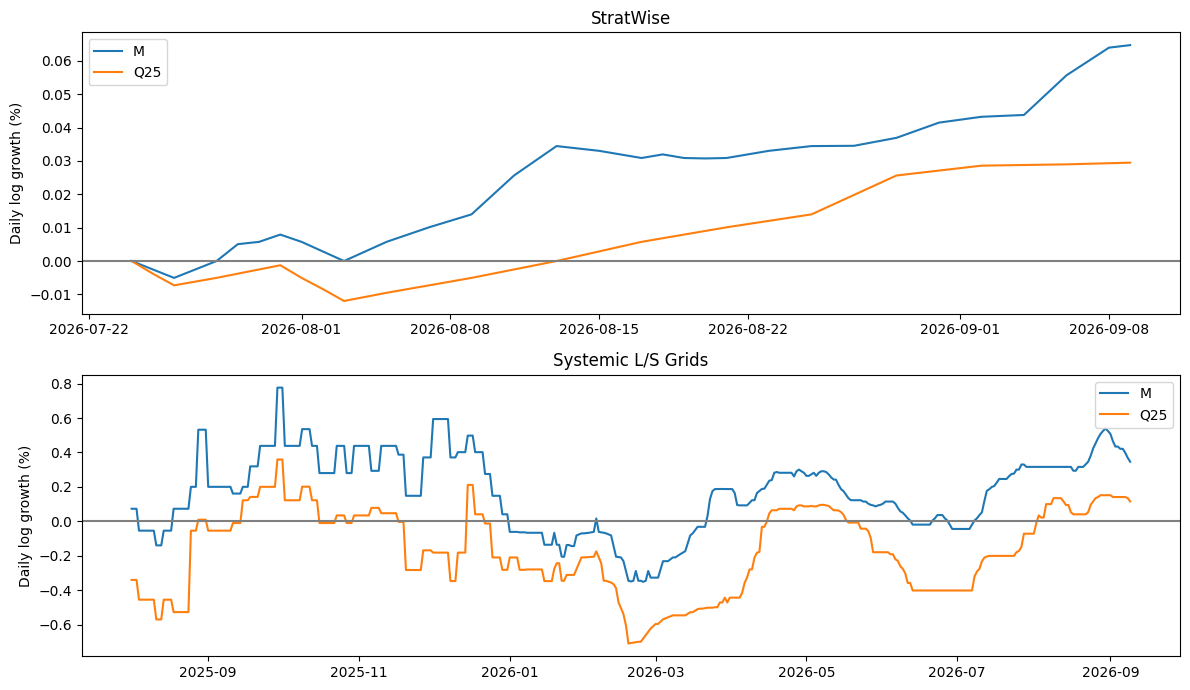

,reference,address,opportunity_rows,q_positive_rows,labelled_30_rows
0,StratWise,0x0ff219ac20596b457558341bc410bc7a08a1394c,41,28,22
1,Systemic L/S Grids,0x07fd993f0fa3a185f7207adccd29f7a87404689d,391,130,372


,finite_rows,q_positive_fraction,q_p_floor_agreement
0,81071,0.143158,0.975873


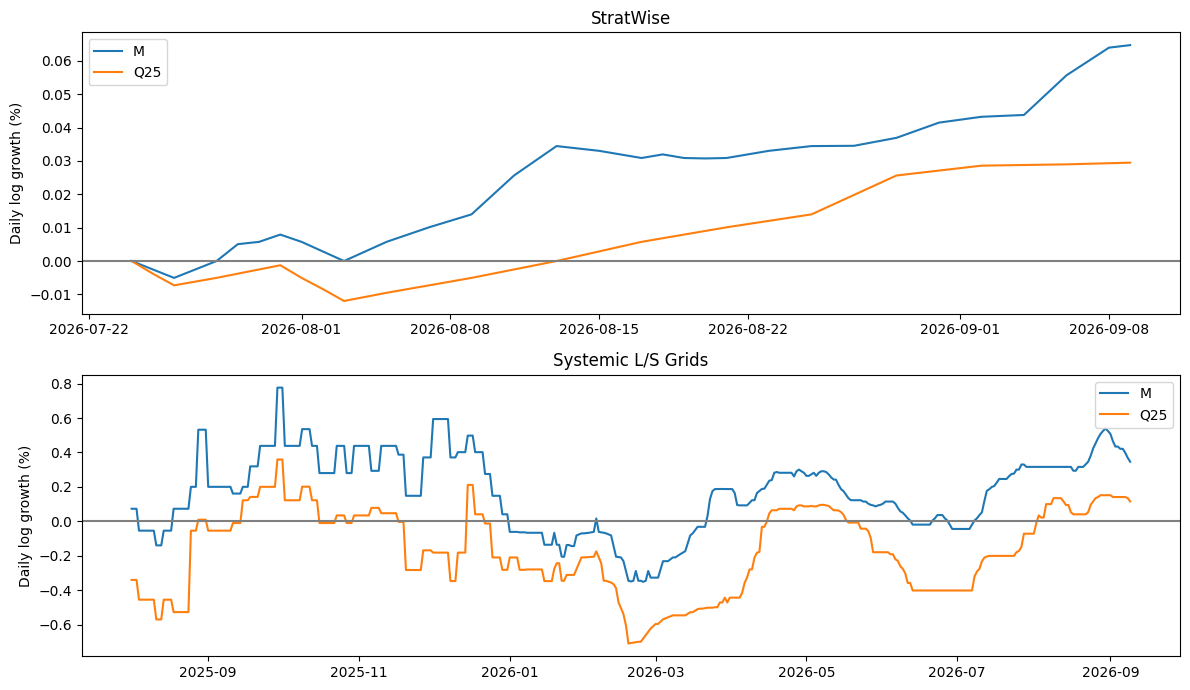

In [6]:
cohorts=[]
for setting in SPECS:
    for label in ['M','Q25']:
        col,hi=score_columns(*setting)[label]
        for key,g in opportunity.groupby(['age_cohort','cadence'],observed=True):
            for horizon in HORIZONS:
                rhos=pd.Series([correlation(d[col],d[f'forward_return_{horizon}']) for _,d in g.groupby('date')]).dropna()
                cohorts.append(dict(setting=str(setting),score=label,age=str(key[0]),cadence=key[1],horizon=horizon,rows=len(g),scored_dates=len(rhos),mean_rho=rhos.mean(),one_event_share=g[f'unique_event_count_{setting[0]}_{setting[1]}'].eq(1).mean()))
pd.DataFrame(cohorts).to_csv(OUT/'cohort-summary.csv',index=False)
robust=[]
for key,g in marginal.groupby(['score','horizon','target']):
    good=g.dropna(subset=['rho'])
    if good.empty: continue
    offset=(pd.to_datetime(good.date)-pd.to_datetime(good.date).min()).dt.days
    nonoverlap=good.loc[offset.mod(key[1]).eq(0)]
    robust.append(dict(score=key[0],horizon=key[1],target=key[2],dates=len(nonoverlap),mean_rho=nonoverlap.rho.mean(),mean_spread=nonoverlap.spread.mean()))
pd.DataFrame(robust).to_csv(OUT/'nonoverlap-summary.csv',index=False)
references={'StratWise':'0x0ff219ac20596b457558341bc410bc7a08a1394c','Systemic L/S Grids':'0x07fd993f0fa3a185f7207adccd29f7a87404689d'}
fig,axes=plt.subplots(2,1,figsize=(12,7))
reference_rows=[]
for ax,(name,address) in zip(axes,references.items()):
    d=panel.loc[panel.address.eq(address)].sort_values('date')
    for prefix,label in [('median_log_rate','M'),('lower_quartile_log_rate','Q25')]:
        ax.plot(d.date,100*d[f'{prefix}_7_60'],label=label)
    ax.axhline(0,color='grey'); ax.set_title(name); ax.set_ylabel('Daily log growth (%)'); ax.legend()
    reference_rows.append(dict(reference=name,address=address,opportunity_rows=int(d.opportunity.sum()),q_positive_rows=int((d.opportunity & d.lower_quartile_log_rate_7_60.gt(0)).sum()),labelled_30_rows=int((d.opportunity & d.forward_return_30.notna()).sum())))
fig.tight_layout(); fig.savefig(OUT/'reference-rolling-features.png',dpi=150); display(fig)
pd.DataFrame(reference_rows).to_csv(OUT/'reference-vaults.csv',index=False)
display(pd.DataFrame(reference_rows))
q=opportunity.lower_quartile_log_rate_7_60
p=opportunity.positive_window_share_7_60
both=q.notna() & p.notna()
overlap=pd.DataFrame([dict(finite_rows=int(both.sum()),q_positive_fraction=q[both].gt(0).mean(),q_p_floor_agreement=q[both].gt(0).eq(p[both].ge(.75)).mean())])
overlap.to_csv(OUT/'q-frequency-overlap.csv',index=False)
display(overlap)

## Corrected findings and remaining limits

Before/after changes include original timestamps, entry labels, ranking repairs and removal of the
hidden Sharpe denominator floor. The 7/60 candidate was selected after earlier inspection.
Coverage, both conditional horizons, Q cohorts, paired outcome-specific contrasts, calendar-block
intervals and reduced-overlap checks run here. Still omitted from the original broad plan:
matched losing-vault case studies, individual-vault influence sensitivity, period-stratified IC
tables and conditional feature-complete comparator coverage. No portfolio validation is claimed.

In [7]:
report=summary.loc[summary.score.isin(['M_7_60','Q25_7_60','P_7_60','S_7_60','-V_7_60']) & summary.target.isin(['return','drawdown'])]
display(report)
lines=['# NB30 corrected results','','Supersedes original NB30. No portfolio backtest or CAGR claim.','',report.to_markdown(index=False),'','## Conditional Q25_7_60 results','',cs.loc[cs.score.eq('Q25_7_60')].to_markdown(index=False)]
(OUT/'results.md').write_text('\n'.join(lines))
manifest=dict(status='executed_corrected_diagnostic',source_hashes=hashes,settings=SPECS,horizons=HORIZONS,decision_contract='T=source_date+1; original timestamps strictly before T',label_contract='last pre-T mark to last at/before T+H; endpoint carry <=7d; path gap <=7d',superseded=OLD.name,panel_rows=len(panel),opportunity_rows=len(opportunity),outputs=sorted(p.name for p in OUT.iterdir() if p.is_file()))
(OUT/'manifest.json').write_text(json.dumps(manifest,indent=2,default=str))

,score,horizon,target,dates,rho_dates,mean_rho,top,rest,spread,top_coverage,rest_coverage
110,-V_7_60,30,drawdown,405,386,0.630781,-0.033344,-0.144999,0.111655,0.591855,0.600510
112,-V_7_60,30,return,405,386,0.098612,-0.002594,-0.029130,0.026536,0.940141,0.948482
115,-V_7_60,60,drawdown,405,356,0.607403,-0.076592,-0.221999,0.145406,0.507569,0.515490
117,-V_7_60,60,return,405,356,0.149423,-0.006465,-0.060382,0.053917,0.855509,0.865457
190,M_7_60,30,drawdown,405,386,0.025734,-0.204030,-0.105612,-0.098417,0.591123,0.600737
192,M_7_60,30,return,405,386,0.024414,-0.046750,-0.018201,-0.028550,0.948067,0.946630
195,M_7_60,60,drawdown,405,356,0.005012,-0.299017,-0.168732,-0.130286,0.505747,0.515991
197,M_7_60,60,return,405,356,0.031046,-0.070799,-0.044661,-0.026137,0.864890,0.863204
230,P_7_60,30,drawdown,405,386,-0.206455,-0.124700,-0.123283,-0.001417,0.577962,0.604028
232,P_7_60,30,return,405,386,0.049530,-0.024378,-0.023786,-0.000593,0.944351,0.947559


1551